<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QFT008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# QFT008: Particle Identity and Statistics
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1000
timesteps = 300
lambda_val = 1.0
seed = 42
np.random.seed(seed)

# Initial state: two identical packets
state = np.zeros(N)
state[400:420] = 2.0   # packet A
state[580:600] = 2.0   # packet B


In [2]:
def evolve(state, timesteps, lambda_val):
    history = []
    s = state.copy()
    for t in range(timesteps):
        # Symmetry kernel: nonlinear + exchange bias
        exchange = np.roll(s, -1) - np.roll(s, 1)
        s = s + lambda_val * np.sin(s) + 0.05 * exchange

        # Optional: antisymmetrize every 50 steps
        if t % 50 == 0:
            s = s - np.mean(s)
        history.append(s.copy())
    return np.array(history)


In [3]:
history = evolve(state, timesteps, lambda_val)


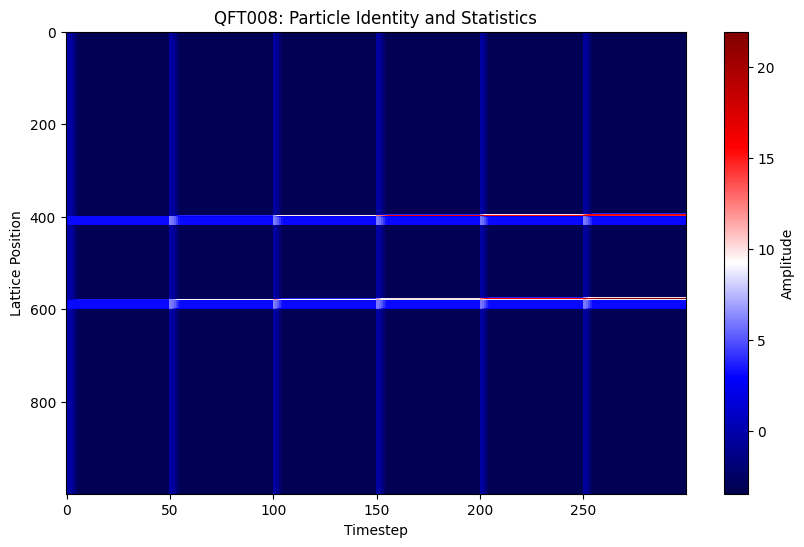

In [4]:
plt.figure(figsize=(10,6))
plt.imshow(history.T, aspect='auto', cmap='seismic', interpolation='none')
plt.xlabel("Timestep")
plt.ylabel("Lattice Position")
plt.title("QFT008: Particle Identity and Statistics")
plt.colorbar(label="Amplitude")
plt.show()
